## Part 2: Dataset Creation 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Policy_Sales_DATA preparation

In [3]:
n = 1000000

In [4]:
customer_id = np.arange(1, n+1)

In [5]:
vehicle_id = np.arange(1, n+1)

In [6]:
customer_id , vehicle_id

(array([      1,       2,       3, ...,  999998,  999999, 1000000],
       shape=(1000000,)),
 array([      1,       2,       3, ...,  999998,  999999, 1000000],
       shape=(1000000,)))

In [7]:
vehicle_value = 100000

In [8]:
tenure = np.random.choice(
    [1,2,3,4],
    size = n,
    p = [0.2,0.3,0.4,0.1]
)

In [9]:
tenure

array([3, 4, 2, ..., 4, 2, 3], shape=(1000000,))

In [10]:
premium = tenure * 100

In [11]:
premium

array([300, 400, 200, ..., 400, 200, 300], shape=(1000000,))

In [12]:
dates = pd.date_range("2024-01-01","2024-12-31")

In [13]:
dates

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', length=366, freq='D')

In [14]:
purchase_date = np.random.choice(dates, n)

In [15]:
purchase_date

array(['2024-02-17T00:00:00.000000000', '2024-04-09T00:00:00.000000000',
       '2024-02-29T00:00:00.000000000', ...,
       '2024-05-29T00:00:00.000000000', '2024-04-26T00:00:00.000000000',
       '2024-02-07T00:00:00.000000000'],
      shape=(1000000,), dtype='datetime64[ns]')

In [16]:
policy_start = pd.to_datetime(purchase_date) + pd.Timedelta(days=365)

In [17]:
policy_start

DatetimeIndex(['2025-02-16', '2025-04-09', '2025-02-28', '2025-06-15',
               '2025-06-12', '2025-10-07', '2025-03-07', '2025-12-20',
               '2025-12-02', '2025-07-19',
               ...
               '2025-09-09', '2025-05-08', '2025-01-10', '2025-01-15',
               '2025-11-17', '2025-02-05', '2025-03-30', '2025-05-29',
               '2025-04-26', '2025-02-06'],
              dtype='datetime64[ns]', length=1000000, freq=None)

In [18]:
policy_end = policy_start + pd.to_timedelta(tenure*365, unit='D')

In [19]:
policy_end

DatetimeIndex(['2028-02-16', '2029-04-08', '2027-02-28', '2028-06-14',
               '2028-06-11', '2028-10-06', '2028-03-06', '2026-12-20',
               '2028-12-01', '2026-07-19',
               ...
               '2027-09-09', '2026-05-08', '2027-01-10', '2028-01-15',
               '2027-11-17', '2027-02-05', '2026-03-30', '2029-05-28',
               '2027-04-26', '2028-02-06'],
              dtype='datetime64[ns]', length=1000000, freq=None)

In [20]:
policy_df = pd.DataFrame({
    "Customer_ID": customer_id,
    "Vehicle_ID": vehicle_id,
    "Vehicle_Value": vehicle_value,
    "Premium": premium,
    "Policy_Purchase_Date": purchase_date,
    "Policy_Start_Date": policy_start,
    "Policy_End_Date": policy_end,
    "Policy_Tenure": tenure
})

In [21]:
policy_df

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure
0,1,1,100000,300,2024-02-17,2025-02-16,2028-02-16,3
1,2,2,100000,400,2024-04-09,2025-04-09,2029-04-08,4
2,3,3,100000,200,2024-02-29,2025-02-28,2027-02-28,2
3,4,4,100000,300,2024-06-15,2025-06-15,2028-06-14,3
4,5,5,100000,300,2024-06-12,2025-06-12,2028-06-11,3
...,...,...,...,...,...,...,...,...
999995,999996,999996,100000,200,2024-02-06,2025-02-05,2027-02-05,2
999996,999997,999997,100000,100,2024-03-30,2025-03-30,2026-03-30,1
999997,999998,999998,100000,400,2024-05-29,2025-05-29,2029-05-28,4
999998,999999,999999,100000,200,2024-04-26,2025-04-26,2027-04-26,2


In [22]:
policy_df.to_csv("policy_sales_data.csv",index=False)

In [23]:
#Claims_DATA preparation

In [24]:
eligible_days = [7,14,21,28]

In [25]:
policy_df["purchase_day"] = policy_df["Policy_Purchase_Date"].dt.day

In [26]:
policy_df

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure,purchase_day
0,1,1,100000,300,2024-02-17,2025-02-16,2028-02-16,3,17
1,2,2,100000,400,2024-04-09,2025-04-09,2029-04-08,4,9
2,3,3,100000,200,2024-02-29,2025-02-28,2027-02-28,2,29
3,4,4,100000,300,2024-06-15,2025-06-15,2028-06-14,3,15
4,5,5,100000,300,2024-06-12,2025-06-12,2028-06-11,3,12
...,...,...,...,...,...,...,...,...,...
999995,999996,999996,100000,200,2024-02-06,2025-02-05,2027-02-05,2,6
999996,999997,999997,100000,100,2024-03-30,2025-03-30,2026-03-30,1,30
999997,999998,999998,100000,400,2024-05-29,2025-05-29,2029-05-28,4,29
999998,999999,999999,100000,200,2024-04-26,2025-04-26,2027-04-26,2,26


In [27]:
eligible = policy_df[policy_df["purchase_day"].isin(eligible_days)]

In [28]:
eligible

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure,purchase_day
5,6,6,100000,300,2024-10-07,2025-10-07,2028-10-06,3,7
6,7,7,100000,300,2024-03-07,2025-03-07,2028-03-06,3,7
16,17,17,100000,100,2024-03-07,2025-03-07,2026-03-07,1,7
27,28,28,100000,300,2024-10-14,2025-10-14,2028-10-13,3,14
30,31,31,100000,200,2024-03-28,2025-03-28,2027-03-28,2,28
...,...,...,...,...,...,...,...,...,...
999969,999970,999970,100000,200,2024-06-28,2025-06-28,2027-06-28,2,28
999981,999982,999982,100000,300,2024-05-14,2025-05-14,2028-05-13,3,14
999985,999986,999986,100000,100,2024-07-21,2025-07-21,2026-07-21,1,21
999988,999989,999989,100000,300,2024-12-07,2025-12-07,2028-12-06,3,7


In [29]:
eligible.shape

(131114, 9)

In [30]:
claims_2025 = eligible.sample(frac=0.30, random_state=42)

In [31]:
claims_2025

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure,purchase_day
458342,458343,458343,100000,100,2024-04-07,2025-04-07,2026-04-07,1,7
606344,606345,606345,100000,300,2024-11-14,2025-11-14,2028-11-13,3,14
790067,790068,790068,100000,100,2024-04-07,2025-04-07,2026-04-07,1,7
594090,594091,594091,100000,100,2024-10-14,2025-10-14,2026-10-14,1,14
917186,917187,917187,100000,300,2024-09-28,2025-09-28,2028-09-27,3,28
...,...,...,...,...,...,...,...,...,...
247611,247612,247612,100000,300,2024-10-07,2025-10-07,2028-10-06,3,7
335215,335216,335216,100000,300,2024-02-14,2025-02-13,2028-02-13,3,14
705615,705616,705616,100000,300,2024-10-14,2025-10-14,2028-10-13,3,14
38902,38903,38903,100000,200,2024-03-07,2025-03-07,2027-03-07,2,7


In [32]:
claims_df = pd.DataFrame({
    "Claim_ID": np.arange(1, len(claims_2025)+1),
    "Customer_ID": claims_2025["Customer_ID"],
    "Vehicle_ID": claims_2025["Vehicle_ID"],
    "Claim_Amount": 10000,
    "Claim_Date": claims_2025["Policy_Start_Date"],
    "Claim_Type": 1
})

In [33]:
# Step 1 - Filter only 4-year tenure policies
four_year_policies = policy_df[policy_df["Policy_Tenure"] == 4]

# Step 2 - Take 10% of them
claims_2026_eligible = four_year_policies.sample(frac=0.10, random_state=42)

# Step 3 - Create 59 days between Jan 1 and Feb 28, 2026
days_2026 = pd.date_range("2026-01-01", "2026-02-28")

# Step 4 - Distribute claims evenly across 59 days
claim_dates_2026 = np.resize(days_2026, len(claims_2026_eligible))

# Step 5 - Check if vehicle already claimed in 2025
already_claimed = set(claims_2025["Vehicle_ID"])

# Step 6 - Assign Claim_Type (2 if claimed before, 1 if first time)
claim_type_2026 = [2 if vid in already_claimed else 1 
                   for vid in claims_2026_eligible["Vehicle_ID"]]

# Step 7 - Build the 2026 claims dataframe
claims_2026_df = pd.DataFrame({
    "Claim_ID": np.arange(len(claims_df)+1, len(claims_df)+len(claims_2026_eligible)+1),
    "Customer_ID": claims_2026_eligible["Customer_ID"].values,
    "Vehicle_ID": claims_2026_eligible["Vehicle_ID"].values,
    "Claim_Amount": 10000,
    "Claim_Date": claim_dates_2026,
    "Claim_Type": claim_type_2026
})

# Step 8 - Combine 2025 and 2026 claims into one final dataframe


claims_df["Claim_Date"] = pd.to_datetime(claims_df["Claim_Date"])

# Now Month will work correctly
claims_df["Month"] = claims_df["Claim_Date"].dt.to_period("M")

claims_df = pd.concat([claims_df, claims_2026_df], ignore_index=True)

In [34]:
claims_df

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type,Month
0,1,458343,458343,10000,2025-04-07,1,2025-04
1,2,606345,606345,10000,2025-11-14,1,2025-11
2,3,790068,790068,10000,2025-04-07,1,2025-04
3,4,594091,594091,10000,2025-10-14,1,2025-10
4,5,917187,917187,10000,2025-09-28,1,2025-09
...,...,...,...,...,...,...,...
49337,49338,656625,656625,10000,2026-02-02,1,NaT
49338,49339,320937,320937,10000,2026-02-03,1,NaT
49339,49340,212854,212854,10000,2026-02-04,1,NaT
49340,49341,540871,540871,10000,2026-02-05,1,NaT


In [42]:
claims_df.to_csv("claims_data.csv",index=False)

In [35]:
merged = policy_df.merge(claims_df, on=["Customer_ID","Vehicle_ID"], how="left")
analysis = merged.groupby("Policy_Tenure").agg({
    "Premium":"sum",
    "Claim_Amount":"sum"
}).fillna(0)
analysis["Profit"] = analysis["Premium"] - analysis["Claim_Amount"]

In [36]:
analysis

,Premium,Claim_Amount,Profit
Policy_Tenure,,,
1,20017300,79210000.0,-59192700.0
2,60040000,118550000.0,-58510000.0
3,119862900,156670000.0,-36807100.0
4,40189200,138990000.0,-98800800.0


In [37]:
total_claims = claims_df["Claim_Amount"].sum()
total_premium = policy_df["Premium"].sum()
loss_ratio = total_claims / total_premium

In [38]:
loss_ratio

np.float64(2.0563125068242303)

In [39]:
future_claims = total_claims * 1.05
future_loss_ratio = future_claims / total_premium

In [40]:
future_loss_ratio 

np.float64(2.1591281321654416)

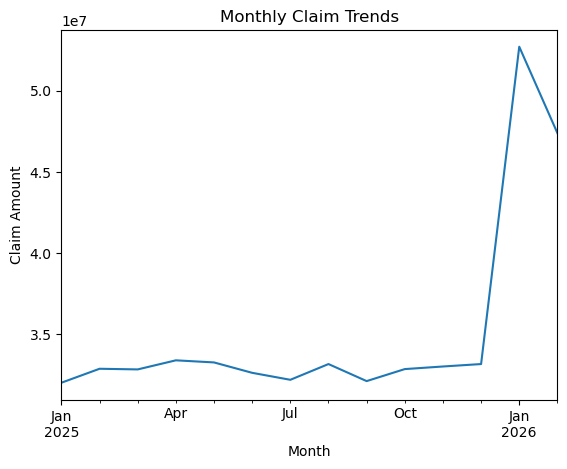

In [41]:
claims_df["Month"] = claims_df["Claim_Date"].dt.to_period("M")

monthly_claims = claims_df.groupby("Month")["Claim_Amount"].sum()

monthly_claims.plot(kind="line")

plt.title("Monthly Claim Trends")
plt.xlabel("Month")
plt.ylabel("Claim Amount")
plt.show()